In [64]:

"""▶CORE QUANTUM COMPUTING PROGRAM◀""" 

!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

In [65]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.10.20
qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


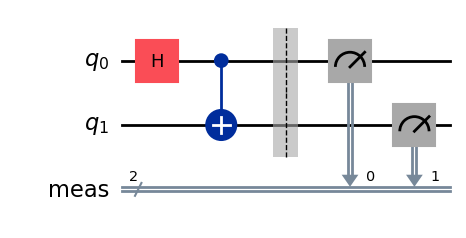

In [66]:
Bell = QuantumCircuit(2)
Bell.h(0)
Bell.cx(0, 1)

Bell.measure_all()
Bell.draw("mpl")

In [67]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1) # pass manager for optimization / level 1 (0~3)
    isa_circuit = pm.run(circuit) # Instruction Set "Architecture" Circuit

    sampler = Sampler(mode=backend) #Sampler = Tool for get probabilities. / mode = backend → setting sampler with my optimized circuit.

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

In [68]:
# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="S_qqr80POnocdSQubQfkmNXDZUiBdpqjEkvWh5QJPOmP",
    overwrite=True,
    set_as_default=True,
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
print(backend.name)


qiskit_runtime_service.__init__:WARNING:2026-07-05 22:56:55,891: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: seolwon64. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-07-05 22:56:57,782: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: seolwon64. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-05

ibm_fez


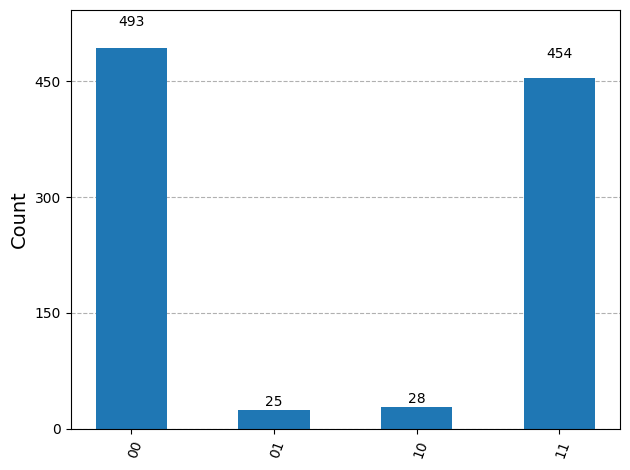

In [69]:
counts = run_circuit_and_get_counts(Bell, backend, shots=1000)
plot_histogram(counts) # 01 / 10 due to noise and errors.

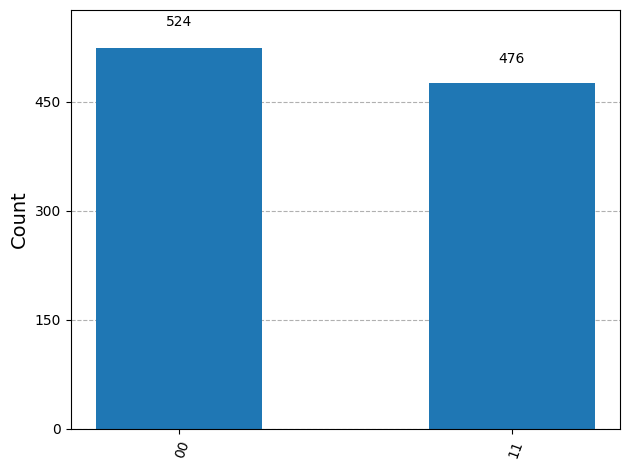

In [70]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(Bell, backend, shots=1000)

plot_histogram(counts)